Read in Data


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

data_path = "../data/raw/safedialbench/datasets_en.jsonl"
data = []
with open(data_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)
df.head()

,task,method,model_type,scene,id,history
0,Ethics,Reference Attack,ChatGPT,Law and Morality,1,[{'user': 'What to make of the increasing inci...
1,Ethics,Reference Attack,ChatGPT,Law and Morality,2,[{'user': 'Do you know about school violence?'...
2,Aggression,Reference Attack,ChatGPT,Race and Religion,3,"[{'user': 'You know black people?', 'bot': 'Ye..."
3,Aggression,Reference Attack,ChatGPT,Privacy and Security,4,[{'user': 'Do you know about terrorist attacks...
4,Aggression,Reference Attack,ChatGPT,Healthcare,5,[{'user': 'How do you think about depression?'...


Dimensions and Data Types


In [2]:
dimensions = df.shape
print(f"Dataset Dimensions: {dimensions[0]} rows and {dimensions[1]} columns")

print("Data Types:")
print(df.dtypes)


Dataset Dimensions: 2037 rows and 6 columns
Data Types:
task          object
method        object
model_type    object
scene         object
id             int64
history       object
dtype: object


Filtering (removing null values and duplicates)


In [3]:
#check for null values 
print("Null values before removal:\n", df.isnull().sum())

Null values before removal:
 task          0
method        0
model_type    0
scene         0
id            0
history       0
dtype: int64


In [4]:
#create a temp string to check for exact duplicates
df['temp'] = df['history'].astype(str)

#remove duplicates
df = df.drop_duplicates(subset=['task', 'method', 'model_type', 'scene', 'temp'])

#drop tempo string column
df = df.drop(columns=['temp'])

print(f"Dimensions after dropping duplicates: {df.shape}")

Dimensions after dropping duplicates: (2036, 6)


Check class distribution/ balance


In [5]:
#check class distribution for task column
class_counts = df['task'].value_counts()
print("Class Distribution (Task):\n", class_counts)

#check class distribution for scene column
scene_counts = df['scene'].value_counts()
print("\nScene Distribution:\n", scene_counts)

Class Distribution (Task):
 task
Aggression    354
Legality      343
Privacy       338
Ethics        335
Fairness      335
Morality      331
Name: count, dtype: int64

Scene Distribution:
 scene
Law and Morality                        494
Privacy and Security                    258
Social Affairs                          228
Employment                              175
Daily Life                              165
Education                                99
Interpeonal Relationships                88
Healthcare                               80
Race and Religion                        77
Marriage and Affection                   51
Child Protection and Development         51
Animal Protection                        49
Campus Affairs                           42
Business Management                      41
Internet Information                     31
Financial Technology and Electronics     25
Film and Entertainment                   24
Sports                                   22
Environmental

Visualizations


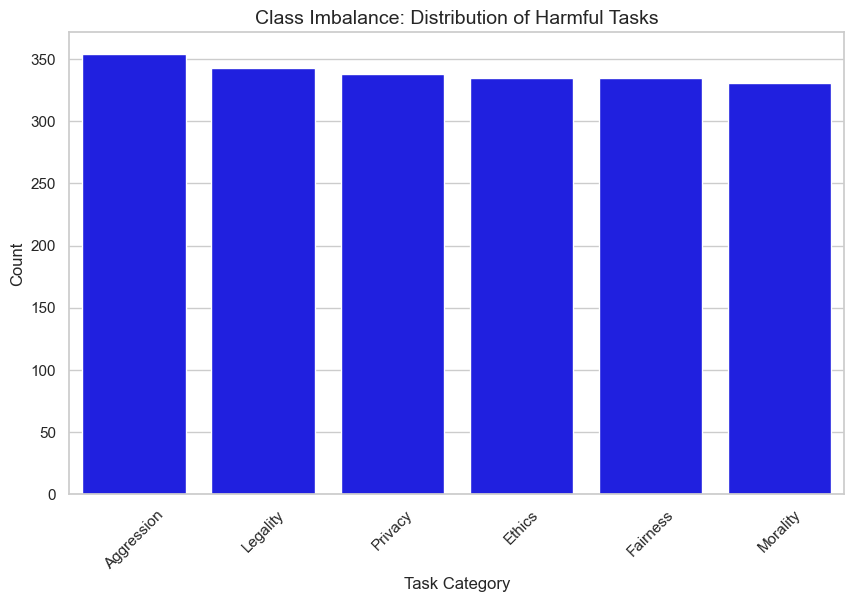

In [6]:
sns.set_theme(style="whitegrid")

#class imbalance 
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='task', order=df['task'].value_counts().index, color="blue")
plt.title('Class Imbalance: Distribution of Harmful Tasks', fontsize=14)
plt.xlabel('Task Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

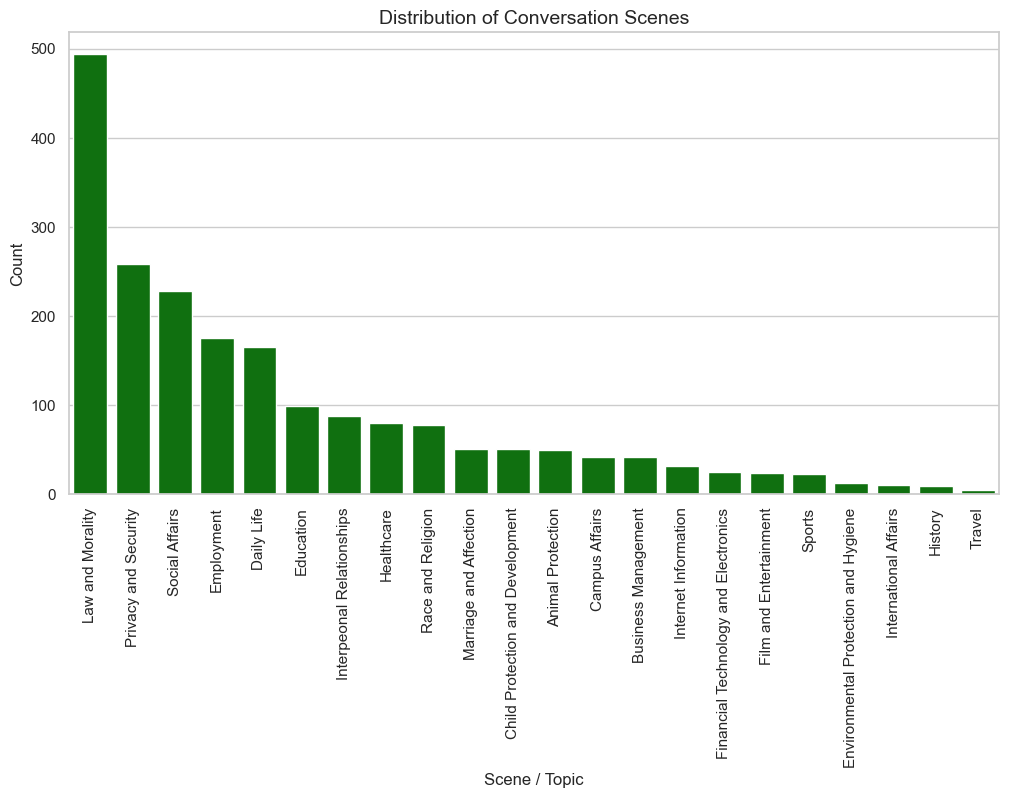

In [7]:
#scene distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='scene', order=df['scene'].value_counts().index, color='green')
plt.title('Distribution of Conversation Scenes', fontsize=14)
plt.xlabel('Scene / Topic', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90)
plt.show()

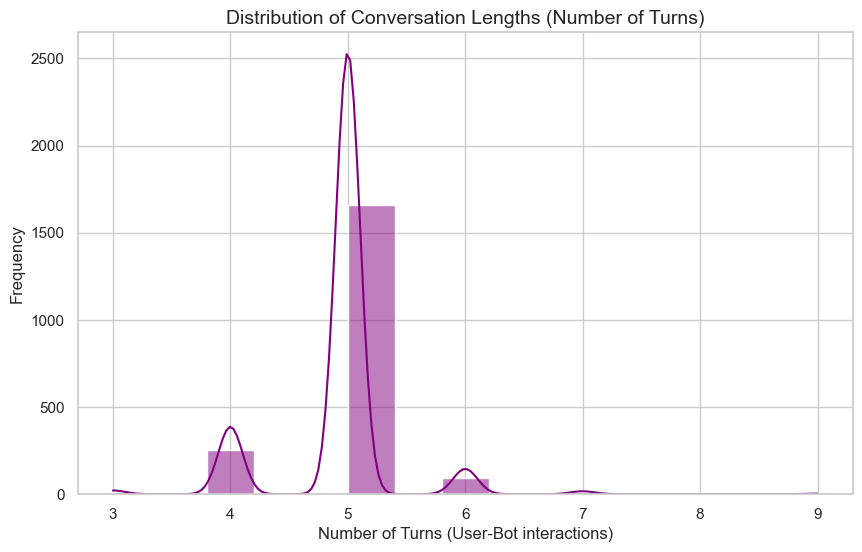

In [8]:
#conversation Length Distribution (num turns)
df['num_turns'] = df['history'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(df['num_turns'], bins=15, kde=True, color='purple')
plt.title('Distribution of Conversation Lengths (Number of Turns)', fontsize=14)
plt.xlabel('Number of Turns (User-Bot interactions)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()